(np.float64(-0.5), np.float64(244.5), np.float64(279.5), np.float64(-0.5))

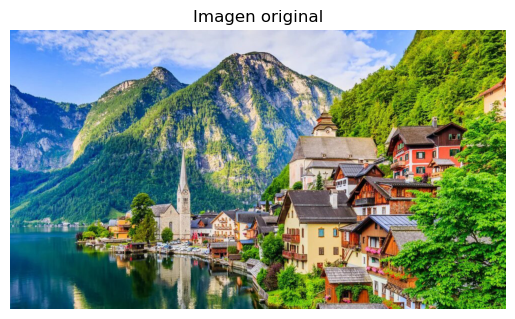

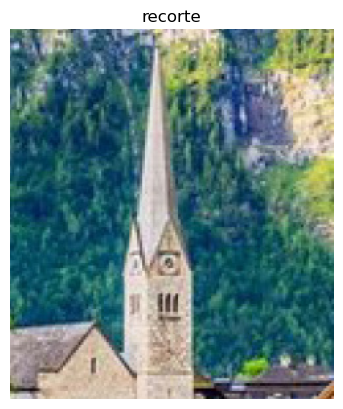

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagenP.jpg.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure()
plt.title("Imagen original")
plt.imshow(img_rgb)
plt.axis('off')

recorte = img_rgb[450:730, 560:805]
plt.figure()
plt.title("recorte")
plt.imshow(recorte)
plt.axis('off')



ejercicio 2

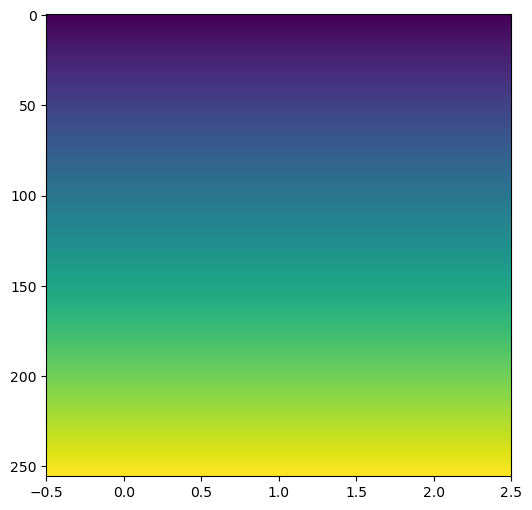

In [73]:
import numpy as np
import matplotlib.pyplot as plt

tamano = 256
imagen = np.zeros((tamano, 3), dtype=np.uint8)

for fila in range(tamano):
    imagen[fila, :] = fila

plt.imshow(imagen, cmap='viridis', aspect='auto')
plt.show()

Ejercicio 3

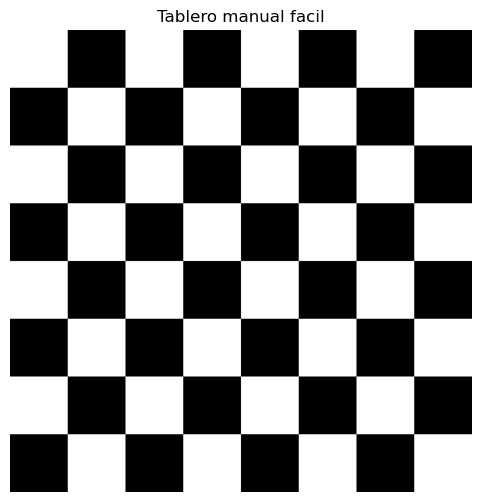

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=[6,6]

tam = 100

imagen = np.ones((tam*8, tam*8, 3), dtype=np.uint8) * 255

negro = [0, 0, 0]

imagen[0:100, 100:200] = negro
imagen[0:100, 300:400] = negro
imagen[0:100, 500:600] = negro
imagen[0:100, 700:800] = negro

imagen[100:200, 0:100] = negro
imagen[100:200, 200:300] = negro
imagen[100:200, 400:500] = negro
imagen[100:200, 600:700] = negro


imagen[200:300, 100:200] = negro
imagen[200:300, 300:400] = negro
imagen[200:300, 500:600] = negro
imagen[200:300, 700:800] = negro


imagen[300:400, 0:100] = negro
imagen[300:400, 200:300] = negro
imagen[300:400, 400:500] = negro
imagen[300:400, 600:700] = negro

imagen[400:500, 100:200] = negro
imagen[400:500, 300:400] = negro
imagen[400:500, 500:600] = negro
imagen[400:500, 700:800] = negro

imagen[500:600, 0:100] = negro
imagen[500:600, 200:300] = negro
imagen[500:600, 400:500] = negro
imagen[500:600, 600:700] = negro

imagen[600:700, 100:200] = negro
imagen[600:700, 300:400] = negro
imagen[600:700, 500:600] = negro
imagen[600:700, 700:800] = negro

imagen[700:800, 0:100] = negro
imagen[700:800, 200:300] = negro
imagen[700:800, 400:500] = negro
imagen[700:800, 600:700] = negro


plt.imshow(imagen)
plt.axis('off')
plt.show()

Ejercicio 4

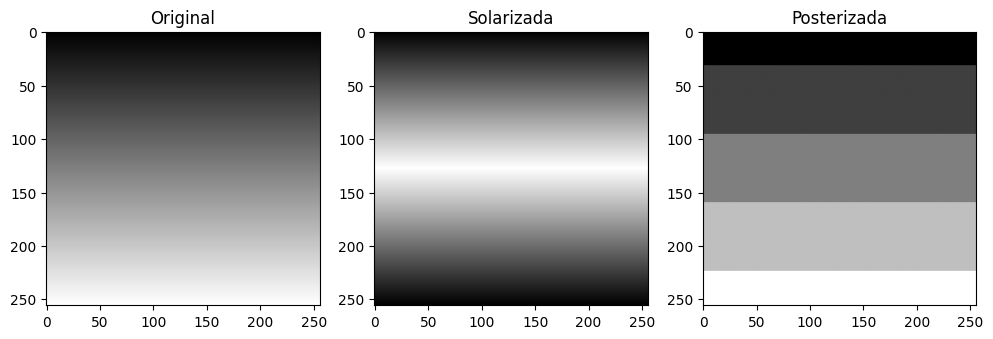

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
tamano = 256
imagen = np.zeros((tamano, tamano, 3), dtype=np.uint8)

for fila in range(tamano):
    imagen[fila, :] = fila
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
def solarizar(imagen, umbral):
    return np.where(imagen < umbral, imagen, 255 - imagen).astype(np.uint8)
def posterizar(imagen, niveles):
    factor = 255 / niveles
    img = np.round(imagen / factor) * factor
    return img.astype(np.uint8)

def falso_color(img_gray, colormap):
    img_norm = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.applyColorMap(img_norm, colormap)
img_solar = solarizar(img_gray, 127)
cv2.imwrite("solarizada.png", img_solar)
img_poster = posterizar(img_gray, 4)
cv2.imwrite("posterizada.png", img_poster)
colormaps = {
    "JET": cv2.COLORMAP_JET,
    "HOT": cv2.COLORMAP_HOT,
    "COOL": cv2.COLORMAP_COOL,
    "SPRING": cv2.COLORMAP_SPRING,
    "SUMMER": cv2.COLORMAP_SUMMER,
    "AUTUMN": cv2.COLORMAP_AUTUMN,
    "WINTER": cv2.COLORMAP_WINTER,
    "BONE": cv2.COLORMAP_BONE,
    "RAINBOW": cv2.COLORMAP_RAINBOW,
    "OCEAN": cv2.COLORMAP_OCEAN,
    "PINK": cv2.COLORMAP_PINK,
    "HSV": cv2.COLORMAP_HSV,
    "PARULA": cv2.COLORMAP_PARULA,
    "MAGMA": cv2.COLORMAP_MAGMA,
    "INFERNO": cv2.COLORMAP_INFERNO,
    "PLASMA": cv2.COLORMAP_PLASMA,
    "VIRIDIS": cv2.COLORMAP_VIRIDIS,
    "CIVIDIS": cv2.COLORMAP_CIVIDIS,
    "TWILIGHT": cv2.COLORMAP_TWILIGHT,
    "TURBO": cv2.COLORMAP_TURBO
}
for nombre, cmap in colormaps.items():
    img_fc = falso_color(img_gray, cmap)
    cv2.imwrite(f"falso_color_{nombre}.png", img_fc)
plt.figure(figsize=(12,6))

plt.subplot(131)
plt.title("Original")
plt.imshow(img_gray, cmap='gray')

plt.subplot(132)
plt.title("Solarizada")
plt.imshow(img_solar, cmap='gray')

plt.subplot(133)
plt.title("Posterizada")
plt.imshow(img_poster, cmap='gray')

plt.show()

Ejercicio 5

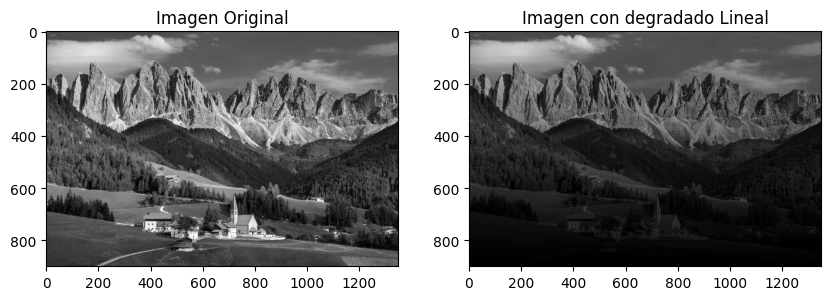

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen=cv2.imread('imagen1.jpg.jpeg',0)

degradado=np.linspace(1,0,imagen.shape[0])[:, np.newaxis]
mascara=np.tile(degradado,(1,imagen.shape[1]))
imagen_degradada=(imagen.astype(np.float32)*mascara).astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(imagen_degradada,cv2.COLOR_BGR2RGB))
plt.title('Imagen con degradado Lineal')
plt.show()

Ejercicio 6

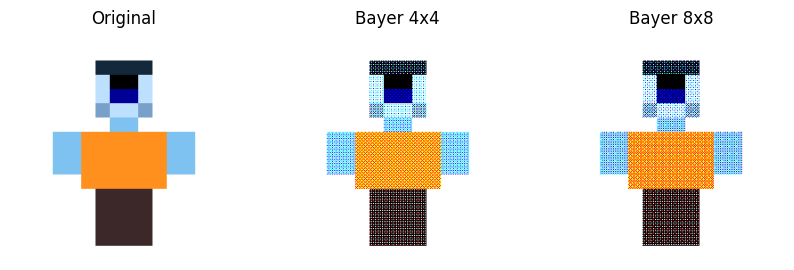

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

h, w = 256, 256
img = np.ones((h, w, 3), dtype=np.uint8) * 255

s = 16

def bloque(x, y, color):
    img[y*s:(y+1)*s, x*s:(x+1)*s] = color

piel1 = [255,224,189]
piel2 = [241,194,125]
sombra = [200,160,120]
cabello = [60,40,20]
camisa = [30,144,255]
pantalon = [40,40,60]

# cabeza (con tonos)
for i in range(6,10):
    for j in range(2,6):
        bloque(i,j,piel1)

bloque(6,2,sombra); bloque(9,2,sombra)
bloque(6,5,sombra); bloque(9,5,sombra)

# cabello
for i in range(6,10):
    bloque(i,2,cabello)

# ojos
bloque(7,3,[0,0,0])
bloque(8,3,[0,0,0])

# boca
bloque(7,4,[150,0,0])
bloque(8,4,[150,0,0])

# cuello
bloque(7,6,piel2)
bloque(8,6,piel2)

# torso
for i in range(5,11):
    for j in range(7,11):
        bloque(i,j,camisa)

# brazos
for i in range(3,5):
    for j in range(7,10):
        bloque(i,j,piel2)
for i in range(11,13):
    for j in range(7,10):
        bloque(i,j,piel2)

# piernas
for i in range(6,8):
    for j in range(11,15):
        bloque(i,j,pantalon)
for i in range(8,10):
    for j in range(11,15):
        bloque(i,j,pantalon)

cv2.imwrite("persona_humana.png", img)

b4 = (1/16)*np.array([
    [0,8,2,10],
    [12,4,14,6],
    [3,11,1,9],
    [15,7,13,5]
])

b8 = (1/64)*np.array([
    [0,48,12,60,3,51,15,63],
    [32,16,44,28,35,19,47,31],
    [8,56,4,52,11,59,7,55],
    [40,24,36,20,43,27,39,23],
    [2,50,14,62,1,49,13,61],
    [34,18,46,30,33,17,45,29],
    [10,58,6,54,9,57,5,53],
    [42,26,38,22,41,25,37,21]
])

def bayer_color(img, m):
    h, w, c = img.shape
    mh, mw = m.shape
    out = np.zeros_like(img)
    for k in range(c):
        for i in range(h):
            for j in range(w):
                t = m[i % mh, j % mw] * 255
                out[i,j,k] = 255 if img[i,j,k] > t else 0
    return out

r4 = bayer_color(img, b4)
r8 = bayer_color(img, b8)

cv2.imwrite("persona_humana_bayer4.png", r4)
cv2.imwrite("persona_humana_bayer8.png", r8)

plt.figure(figsize=(10,5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(132)
plt.imshow(cv2.cvtColor(r4, cv2.COLOR_BGR2RGB))
plt.title("Bayer 4x4")
plt.axis('off')

plt.subplot(133)
plt.imshow(cv2.cvtColor(r8, cv2.COLOR_BGR2RGB))
plt.title("Bayer 8x8")
plt.axis('off')

plt.show()